In [453]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [454]:
df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e2/train.csv')

In [455]:
df_train = df_train.drop('id',axis=1)

In [456]:
df_train.shape

(630000, 14)

In [457]:
df_train.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [458]:
df_train.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


<Axes: xlabel='Cholesterol'>

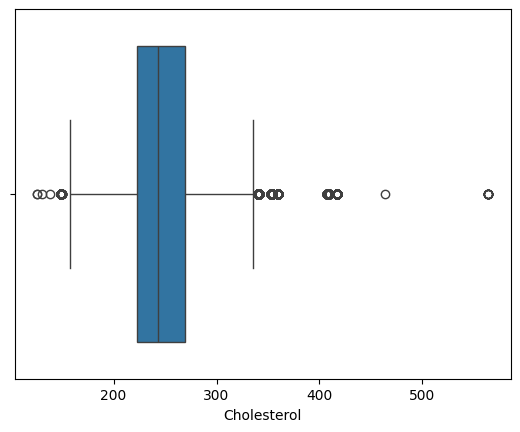

In [459]:
sns.boxplot(data=df_train,  x='Cholesterol')

In [460]:
diff_chol = df_train.describe().loc['75%']['Cholesterol'] - df_train.describe().loc['25%']['Cholesterol']

In [461]:
low = df_train.describe().loc['25%']['Cholesterol'] - 1.5 * diff_chol
high = df_train.describe().loc['75%']['Cholesterol'] + 1.5 * diff_chol

In [462]:
df_train = df_train[(df_train['Cholesterol'] >= low) & (df_train['Cholesterol'] <= high)]

<Axes: xlabel='Cholesterol'>

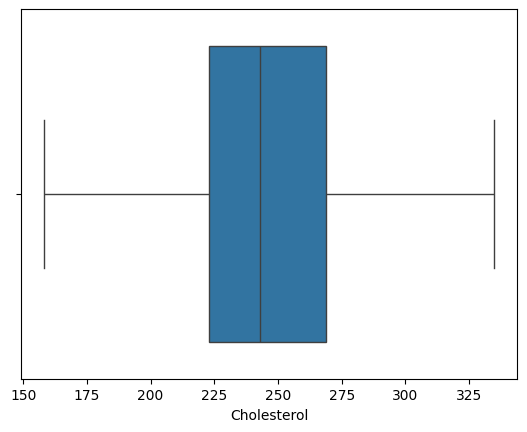

In [463]:
sns.boxplot(data=df_train,  x='Cholesterol')

<Axes: xlabel='ST depression'>

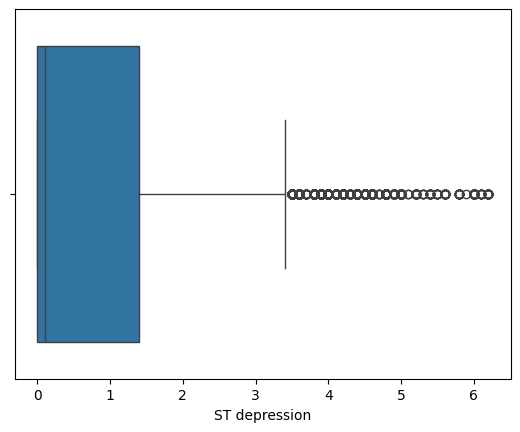

In [464]:
sns.boxplot(df_train, x='ST depression')

In [465]:
diff_st_dep = df_train.describe().loc['75%']['ST depression'] - df_train.describe().loc['25%']['ST depression']

In [466]:
high = df_train.describe().loc['75%']['ST depression'] + 1.2 * diff_st_dep

In [467]:
df_train = df_train[df_train['ST depression'] < high]

<Axes: xlabel='ST depression'>

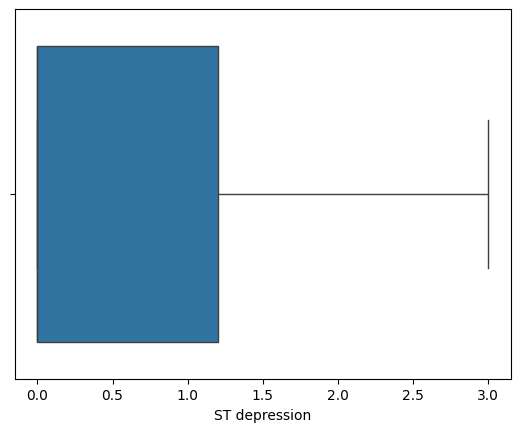

In [468]:
sns.boxplot(df_train, x='ST depression')

In [469]:
df_train['Heart Disease'] = df_train['Heart Disease'].apply(lambda x: 1 if x == 'Presence' else 0)

In [470]:
X = df_train.drop('Heart Disease',axis=1)
y = df_train['Heart Disease']

In [471]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [472]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [473]:
scaler = StandardScaler()
poly = PolynomialFeatures(include_bias=False)

In [474]:
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [475]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [476]:
X_train.shape, y_train.shape

((489451, 104), (489451,))

In [477]:
from keras import Sequential
from keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam

In [598]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

In [599]:
model.compile(optimizer=Adam(learning_rate=0.00005), loss='binary_crossentropy', metrics=['accuracy'])

In [600]:
model.fit(X_train,y_train, validation_split=0.2, epochs=10, batch_size=1024)

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7536 - loss: 0.4916 - val_accuracy: 0.8782 - val_loss: 0.2934
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8684 - loss: 0.3174 - val_accuracy: 0.8815 - val_loss: 0.2868
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8733 - loss: 0.3071 - val_accuracy: 0.8825 - val_loss: 0.2845
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8754 - loss: 0.3024 - val_accuracy: 0.8830 - val_loss: 0.2831
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8779 - loss: 0.2973 - val_accuracy: 0.8833 - val_loss: 0.2821
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8794 - loss: 0.2923 - val_accuracy: 0.8833 - val_loss: 0.2812
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8810 - loss: 0.2899 - val_accuracy: 0.8836 - val_loss: 0.2806
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8807 - loss: 0.2899 - val_accuracy: 0.

In [601]:
model.evaluate(X_test, y_test)

3824/3824 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8818 - loss: 0.2813


[0.27969256043434143, 0.8831182718276978]

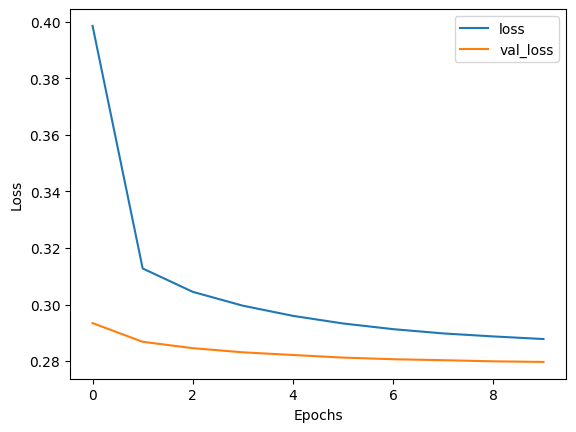

In [602]:
plt.plot(model.history.history['loss'], label='loss')
plt.plot(model.history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [494]:
y_pred = model.predict(X_test)

3824/3824 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [484]:
from sklearn.metrics import classification_report

In [485]:
y_pred = (y_pred > 0.5).astype(int)

In [486]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90     68998
           1       0.87      0.86      0.87     53365

    accuracy                           0.88    122363
   macro avg       0.88      0.88      0.88    122363
weighted avg       0.88      0.88      0.88    122363



In [487]:
y_pred_test = model.predict(X_test)

3824/3824 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [564]:
model.save('heart_disease_model.keras')